Shopify Financial Analysis


project done bY :
Mohamed Nalif
Linkedin:[link text](https://www.linkedin.com/in/mohamednalif)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Executive Summary

## Project Overview

This project analyzes Shopify sales data to uncover key business insights related to customer purchasing behavior, product performance, profitability, shipping costs, discounts, and product returns. The analysis combines Python, SQL, statistical techniques, machine learning, and business intelligence to transform raw transactional data into actionable business recommendations.

## Objectives

* Evaluate overall sales and profitability.
* Analyze customer purchasing behavior across countries.
* Identify top-performing and low-performing products.
* Measure the impact of discounts and shipping costs on profit.
* Analyze product return patterns.
* Perform statistical tests to validate business assumptions.
* Build predictive models to forecast business outcomes.
* Develop an interactive Power BI dashboard for decision-making.

## Tools & Technologies

* Python (Pandas, NumPy)
* Matplotlib & Seaborn
* SQL (SQLite)
* SciPy (Statistical Analysis)
* Scikit-learn (Machine Learning)
* Power BI

## Project Workflow

1. Data Quality Assessment
2. Data Cleaning & Preparation
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. SQL Business Analysis
6. Statistical Analysis
7. Predictive Analysis
8. Power BI Dashboard
9. Business Recommendations

## Expected Business Outcomes

* Identify the products contributing the highest revenue and profit.
* Understand the relationship between discounts, shipping costs, and profitability.
* Analyze customer return behavior across product categories and countries.
* Discover factors influencing product returns.
* Provide data-driven recommendations to improve profitability and customer satisfaction.


In [2]:
Shopify = pd.read_csv(r"/content/Shopify/shopify_sales_dataset_ml_eda.csv")

In [3]:
Shopify.shape

(60000, 17)

In [4]:
Shopify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

In [5]:
Shopify.describe()

,order_id,customer_id,product_id,product_price,discount_percent,quantity,shipping_cost,rating,is_returned,discounted_price,revenue,profit
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,30000.500000,30035.075600,4504.738650,403.427068,18.151500,3.009567,13.521758,3.002440,0.148117,330.220212,994.098926,980.577168
std,17320.652413,11540.753215,2018.287018,230.045257,12.527663,1.414794,6.627934,1.152265,0.355219,197.114822,806.445785,806.508355
min,1.000000,10000.000000,1000.000000,5.010000,0.000000,1.000000,2.000000,1.000000,0.000000,3.080000,3.080000,-20.490000
25%,15000.750000,20037.750000,2751.750000,203.160000,5.000000,2.000000,7.760000,2.000000,0.000000,161.957500,355.620000,341.925000
50%,30000.500000,30079.000000,4503.500000,403.855000,20.000000,3.000000,13.580000,3.000000,0.000000,322.560000,760.470000,747.275000
75%,45000.250000,40036.250000,6257.000000,603.135000,30.000000,4.000000,19.230000,4.000000,0.000000,482.242500,1462.450000,1449.807500
max,60000.000000,49999.000000,7999.000000,799.990000,40.000000,5.000000,25.000000,5.000000,1.000000,799.900000,3999.500000,3989.950000


In [6]:
###. Data Quality Assessment:

In [7]:
def quality_assessment(df):
    print("-------- Data Quality Assessment --------")
    print("Missing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0])  # Only show columns with missing
    if missing.sum() == 0:
        print("No missing values found.")
    else:
        print(f"Total missing values: {missing.sum()}")

    print("\nDuplicates:")
    duplicates = df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicates}")
    if duplicates > 0:
        print("Consider dropping with df.drop_duplicates() or subset-based logic.")
quality_assessment(Shopify)

-------- Data Quality Assessment --------
Missing Values:
Series([], dtype: int64)
No missing values found.

Duplicates:
Number of duplicate rows: 0


In [8]:
###.Data Cleaning :
Shopify['order_date'] = pd.to_datetime(Shopify['order_date'])

In [9]:
###.Univarient Analysis:


In [10]:
def univariate_analysis(data, column_name=None):
    """
    Perform Univariate Analysis on a numerical column.
    Works with both Series and DataFrame + column name.
    """
    print("===== Univariate Analysis =====")

    # Convert to Series if DataFrame is passed with column_name
    if isinstance(data, pd.DataFrame) and column_name:
        series = data[column_name]
        col_name = column_name
    else:
        series = pd.Series(data) if not isinstance(data, pd.Series) else data
        col_name = series.name if series.name else 'Variable'

    # Basic statistics
    print(f"Column: {col_name}")
    print(f"Count          : {series.count():,}")
    print(f"Mean           : {series.mean():,.4f}")
    print(f"Median         : {series.median():,.4f}")
    print(f"Mode           : {series.mode().iloc[0] if not series.mode().empty else 'N/A'}")
    print(f"Standard Dev   : {series.std():,.4f}")
    print(f"Variance       : {series.var():,.4f}")
    print(f"Minimum        : {series.min():,.4f}")
    print(f"Maximum        : {series.max():,.4f}")
    print(f"Range          : {series.max() - series.min():,.4f}")
    print(f"Skewness       : {series.skew():.4f}")      # <0 = left skew, >0 = right skew
    print(f"Kurtosis       : {series.kurtosis():.4f}") # >3 = heavy tails
    print(f"25th Percentile: {series.quantile(0.25):,.4f}")
    print(f"75th Percentile: {series.quantile(0.75):,.4f}")
    print(f"IQR            : {series.quantile(0.75) - series.quantile(0.25):,.4f}")

    # Missing values
    missing = series.isnull().sum()
    print(f"Missing Values : {missing} ({missing/len(series)*100:.2f}%)")

    print("-" * 40)
univariate_analysis(Shopify, 'revenue')

===== Univariate Analysis =====
Column: revenue
Count          : 60,000
Mean           : 994.0989
Median         : 760.4700
Mode           : 146.28
Standard Dev   : 806.4458
Variance       : 650,354.8045
Minimum        : 3.0800
Maximum        : 3,999.5000
Range          : 3,996.4200
Skewness       : 1.0170
Kurtosis       : 0.4323
25th Percentile: 355.6200
75th Percentile: 1,462.4500
IQR            : 1,106.8300
Missing Values : 0 (0.00%)
----------------------------------------


In [11]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    return lower, upper, len(outliers)
detect_outliers(Shopify, 'revenue')

revenue: 1014 outliers (1.69%)


(np.float64(-1304.625), np.float64(3122.6949999999997), 1014)

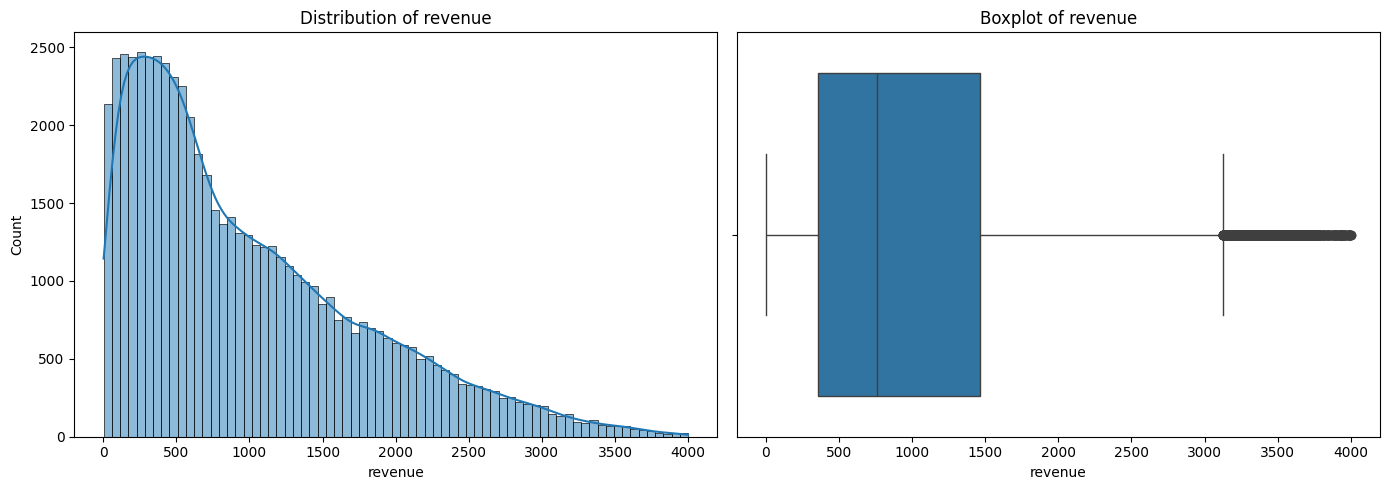

In [12]:
def plot_univariate(series, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram + KDE
    sns.histplot(series, kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {title or series.name}')

    # Boxplot
    sns.boxplot(x=series, ax=axes[1])
    axes[1].set_title(f'Boxplot of {title or series.name}')

    plt.tight_layout()
    plt.show()

# Usage
plot_univariate(Shopify['revenue'])

===== Univariate Analysis =====
Column: profit
Count          : 60,000
Mean           : 980.5772
Median         : 747.2750
Mode           : 53.82
Standard Dev   : 806.5084
Variance       : 650,455.7273
Minimum        : -20.4900
Maximum        : 3,989.9500
Range          : 4,010.4400
Skewness       : 1.0169
Kurtosis       : 0.4320
25th Percentile: 341.9250
75th Percentile: 1,449.8075
IQR            : 1,107.8825
Missing Values : 0 (0.00%)
----------------------------------------
profit: 1012 outliers (1.69%)


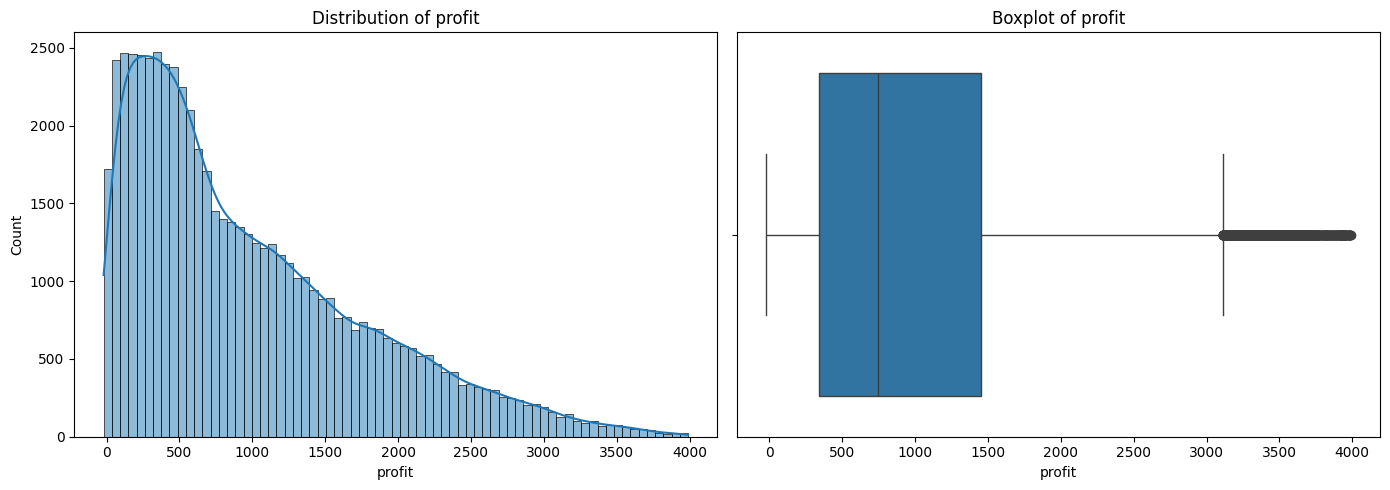

In [13]:
univariate_analysis(Shopify, 'profit')
detect_outliers(Shopify, 'profit')
plot_univariate(Shopify['profit'])

===== Univariate Analysis =====
Column: discounted_price
Count          : 60,000
Mean           : 330.2202
Median         : 322.5600
Mode           : 100.3
Standard Dev   : 197.1148
Variance       : 38,854.2530
Minimum        : 3.0800
Maximum        : 799.9000
Range          : 796.8200
Skewness       : 0.1982
Kurtosis       : -0.9465
25th Percentile: 161.9575
75th Percentile: 482.2425
IQR            : 320.2850
Missing Values : 0 (0.00%)
----------------------------------------
discounted_price: 0 outliers (0.00%)


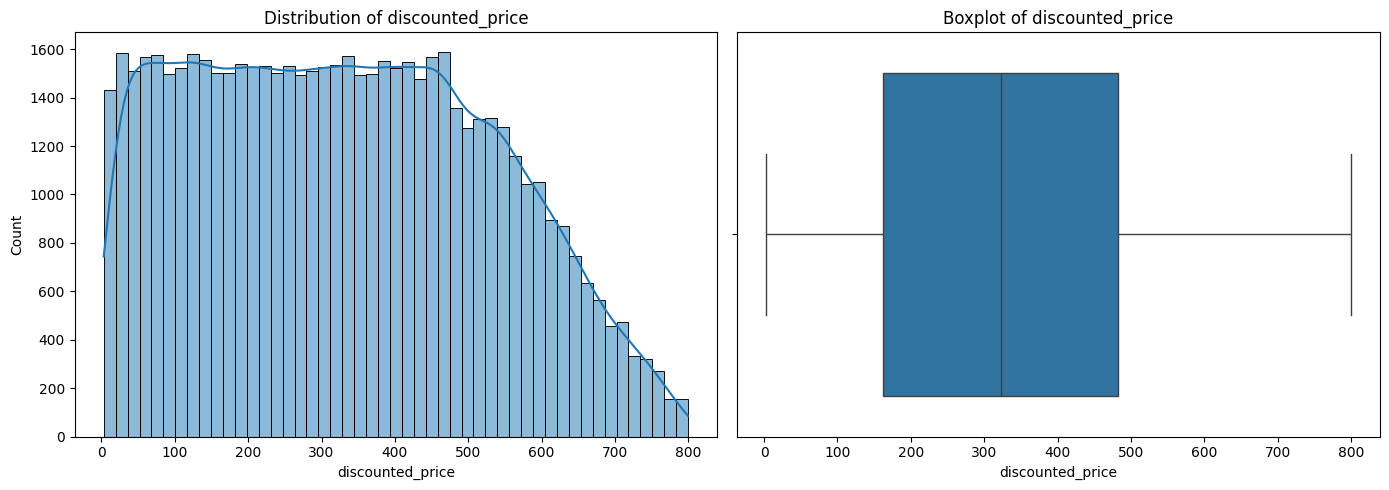

In [14]:
univariate_analysis(Shopify, 'discounted_price')
detect_outliers(Shopify, 'discounted_price')
plot_univariate(Shopify['discounted_price'])

===== Univariate Analysis =====
Column: shipping_cost
Count          : 60,000
Mean           : 13.5218
Median         : 13.5800
Mode           : 10.94
Standard Dev   : 6.6279
Variance       : 43.9295
Minimum        : 2.0000
Maximum        : 25.0000
Range          : 23.0000
Skewness       : -0.0051
Kurtosis       : -1.1977
25th Percentile: 7.7600
75th Percentile: 19.2300
IQR            : 11.4700
Missing Values : 0 (0.00%)
----------------------------------------
shipping_cost: 0 outliers (0.00%)


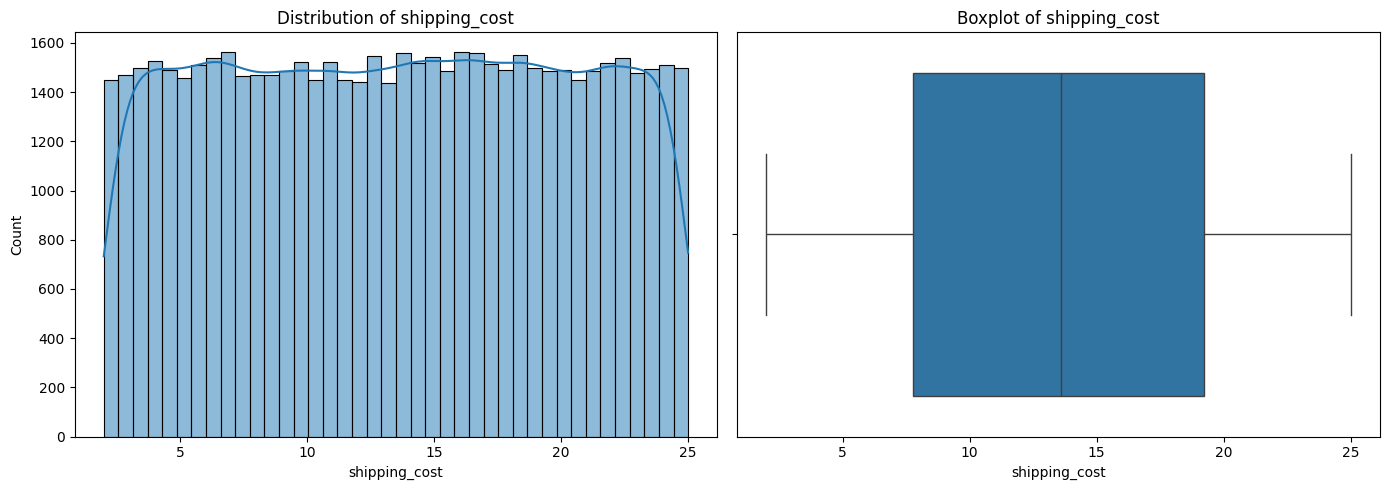

In [15]:

univariate_analysis(Shopify, 'shipping_cost')
detect_outliers(Shopify, 'shipping_cost')
plot_univariate(Shopify['shipping_cost'])

In [16]:
###.Bivarient Analysis:

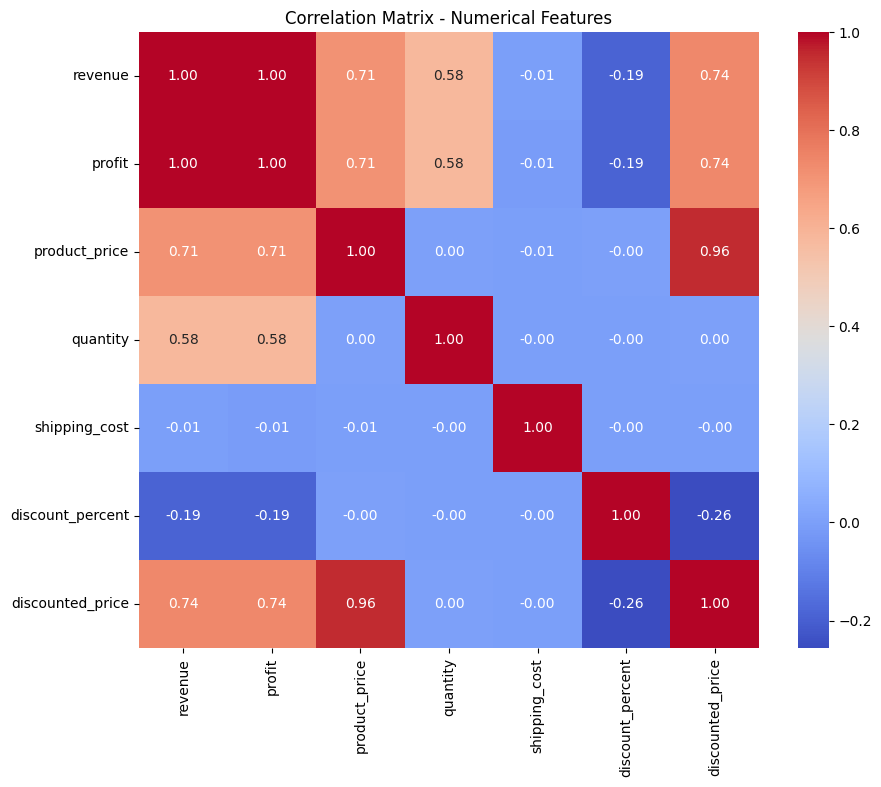

Key Insights from Correlation:
revenue             1.000000
profit              0.999966
discounted_price    0.739114
product_price       0.706162
quantity            0.579274
shipping_cost      -0.005331
discount_percent   -0.188741
Name: revenue, dtype: float64


In [17]:
# Numerical-Numerical: Correlation Matrix + Heatmap
numeric_cols = ['revenue', 'profit', 'product_price', 'quantity', 'shipping_cost',
                'discount_percent', 'discounted_price']

corr_matrix = Shopify[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix - Numerical Features")
plt.show()

print("Key Insights from Correlation:")
print(corr_matrix['revenue'].sort_values(ascending=False))

Average Revenue by product_category:
product_category
Accessories     999.09
Beauty          995.21
Electronics    1010.82
Fashion         982.67
Footwear        987.23
Home Decor      993.70
Sports          989.76
Name: revenue, dtype: float64


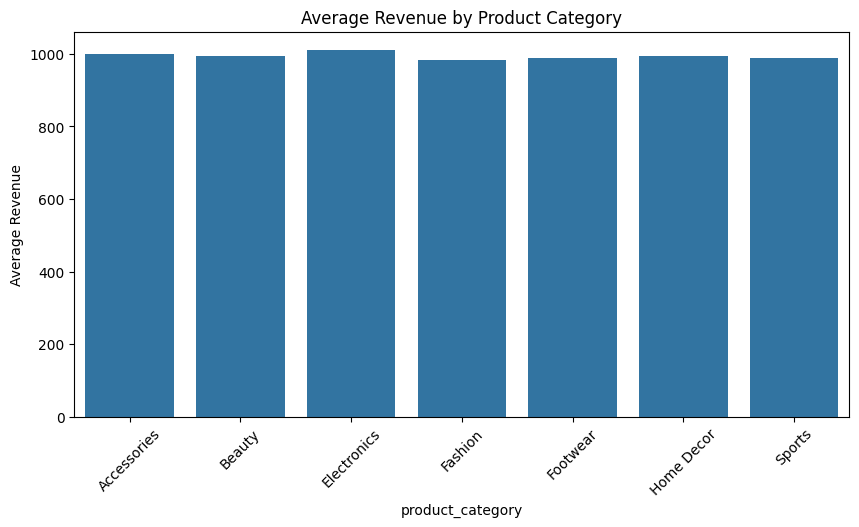

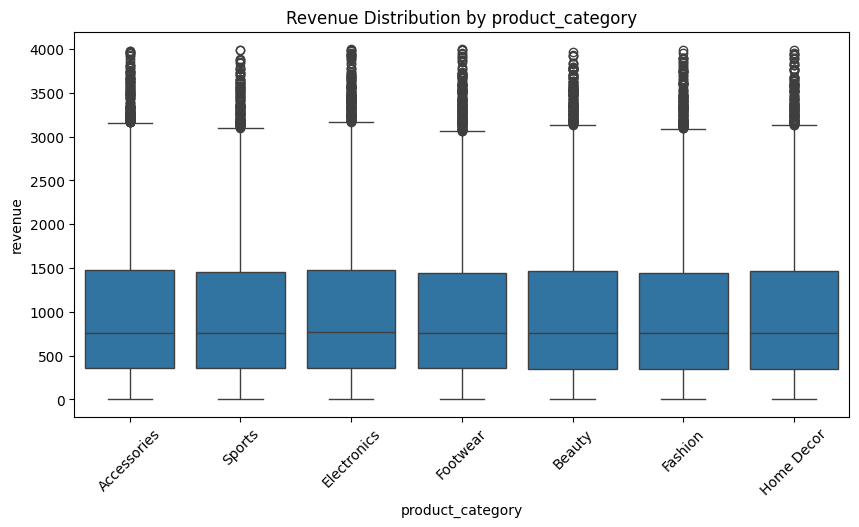

In [18]:
def plot_avg_revenue(df, column, title=None):
    avg_revenue = df.groupby(column)['revenue'].mean().round(2)
    print(f"Average Revenue by {column}:")
    print(avg_revenue)

    # Bar plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x=avg_revenue.index, y=avg_revenue.values)
    plt.title(title or f"Average Revenue by {column}")
    plt.xlabel(column)
    plt.ylabel("Average Revenue")
    plt.xticks(rotation=45)
    plt.show()

    # Boxplot for distribution
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=column, y='revenue', data=df)
    plt.title(f"Revenue Distribution by {column}")
    plt.xticks(rotation=45)
    plt.show()


plot_avg_revenue(Shopify, 'product_category', "Average Revenue by Product Category")


Average Revenue by customer_country:
customer_country
Australia    998.27
Canada       990.76
Germany      995.47
India        994.76
UAE          993.28
UK           988.20
USA          997.87
Name: revenue, dtype: float64


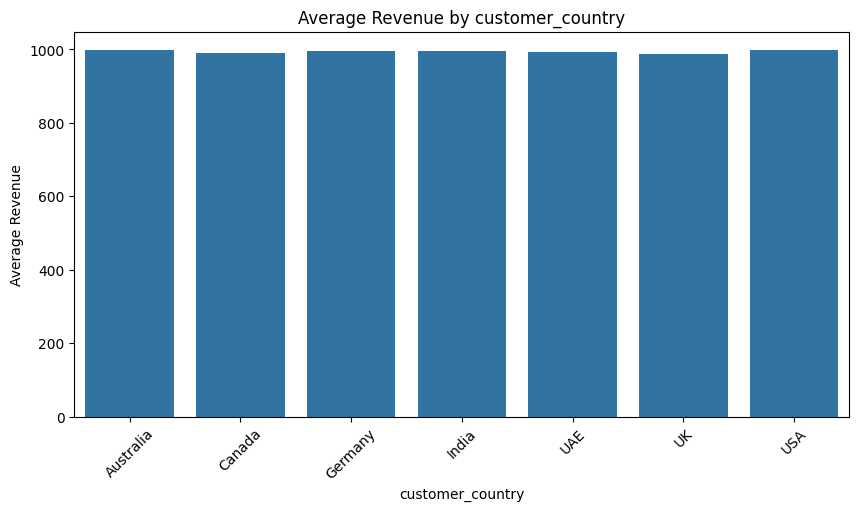

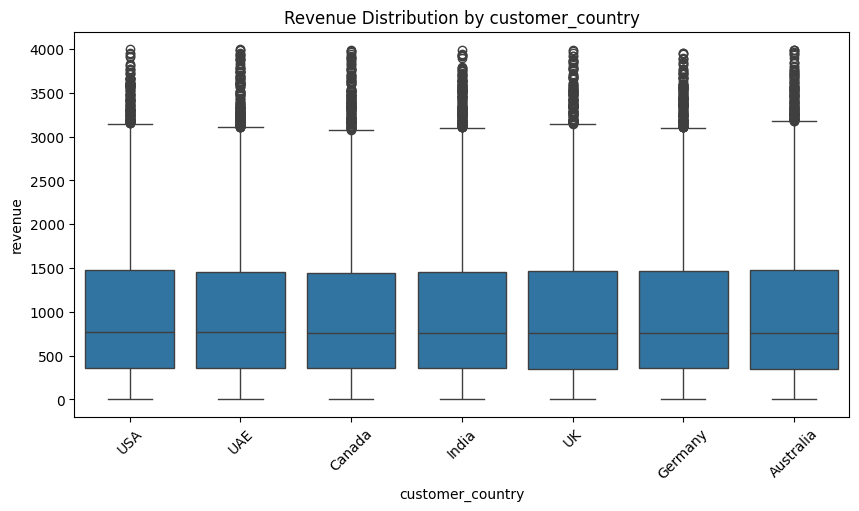

In [19]:
plot_avg_revenue(Shopify, 'customer_country')


Average Revenue by traffic_source:
traffic_source
Direct          999.34
Email           991.78
Organic         986.14
Paid Ads        993.46
Social Media    999.82
Name: revenue, dtype: float64


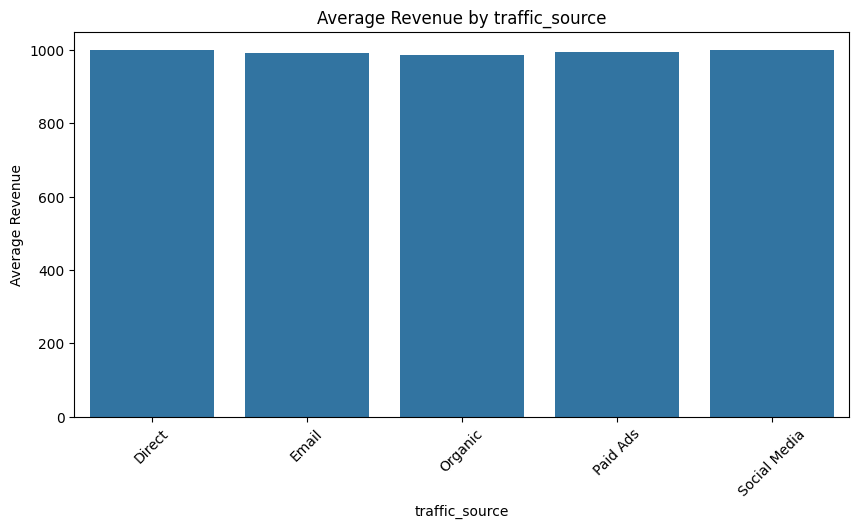

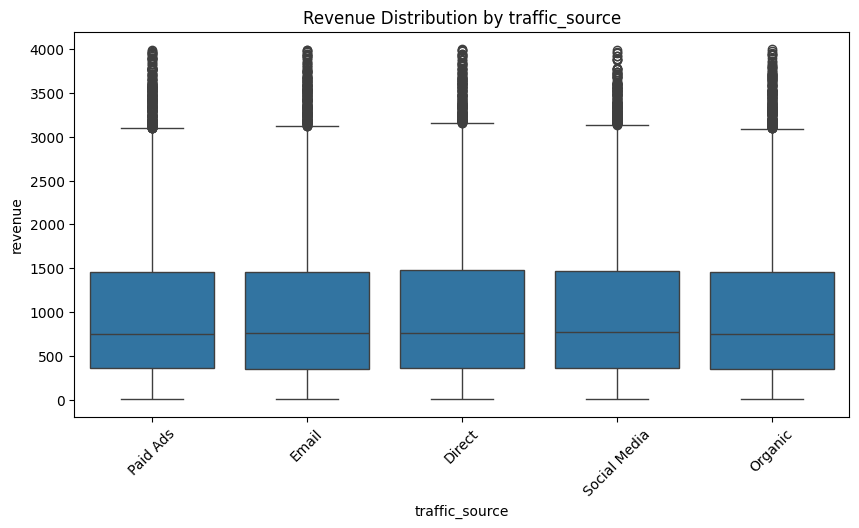

In [20]:
plot_avg_revenue(Shopify, 'traffic_source')


Average Revenue by payment_method:
payment_method
Apple Pay           999.50
Cash on Delivery    986.59
Credit Card         991.69
Debit Card          997.25
PayPal              995.46
Name: revenue, dtype: float64


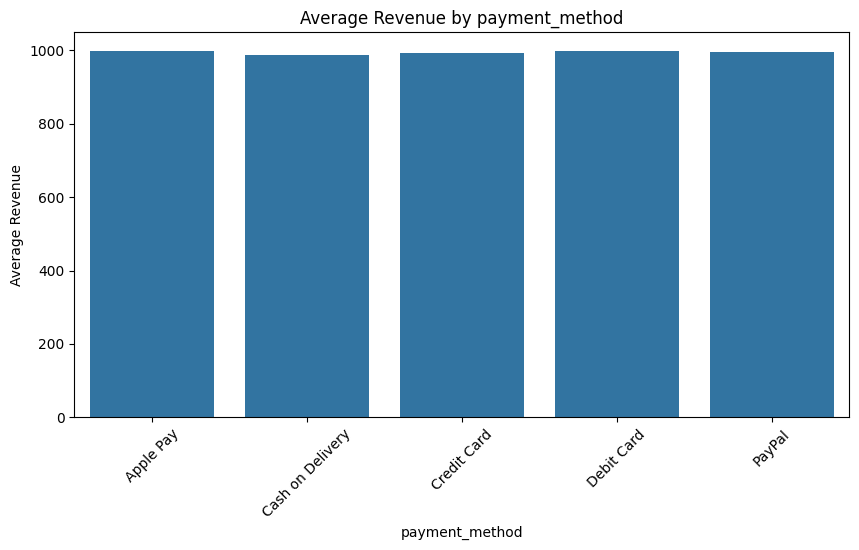

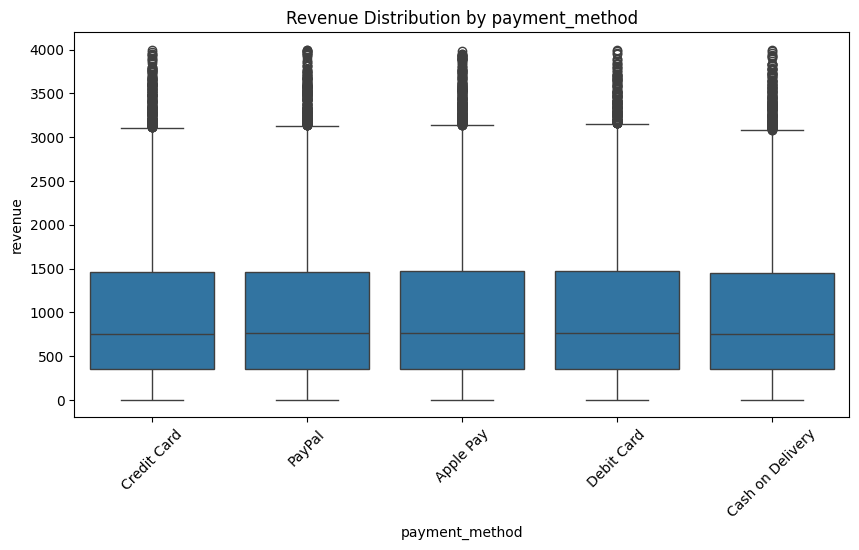

In [21]:
plot_avg_revenue(Shopify, 'payment_method')

In [22]:
#.Time Based:

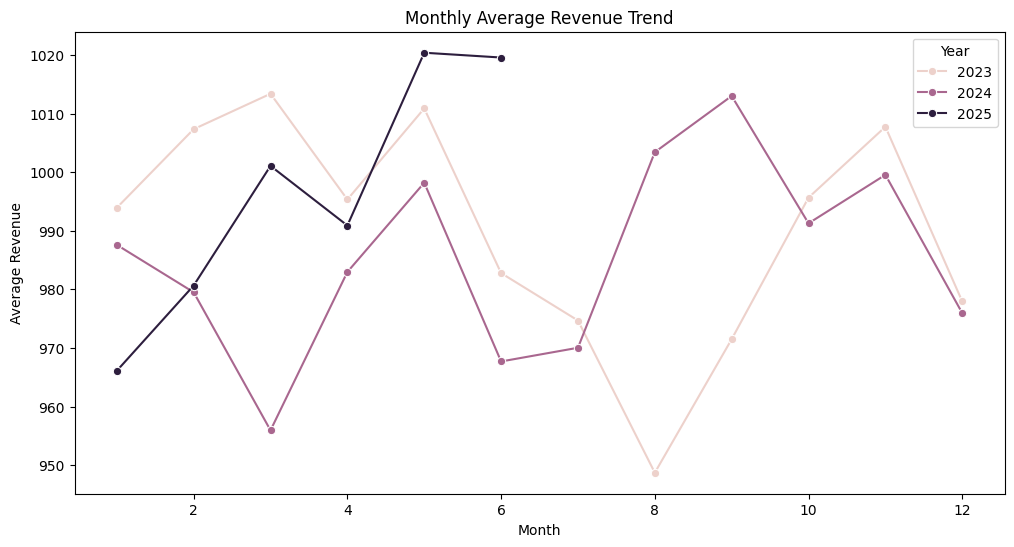

,year,month,revenue
0,2023,1,993.927299
1,2023,2,1007.346621
2,2023,3,1013.389985
3,2023,4,995.341790
4,2023,5,1010.884162
5,2023,6,982.776598
6,2023,7,974.683819
7,2023,8,948.700585
8,2023,9,971.496664
9,2023,10,995.661863


In [53]:
def Revenue_Trend(df, date_column='order_date'):
    # Ensure datetime
    df[date_column] = pd.to_datetime(df[date_column])
    df['year'] = df[date_column].dt.year
    df['month'] = df[date_column].dt.month

    # Monthly average revenue
    monthly_revenue = df.groupby(['year', 'month'])['revenue'].mean().reset_index()

    # Plot
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=monthly_revenue, x='month', y='revenue', hue='year', marker='o')
    plt.title("Monthly Average Revenue Trend")
    plt.xlabel("Month")
    plt.ylabel("Average Revenue")
    plt.legend(title="Year")
    plt.show()

    return monthly_revenue

# Call it
Revenue_Trend(Shopify)

Return Rate (%) by Product Category:
is_returned           0      1
product_category              
Accessories       85.35  14.65
Beauty            84.99  15.01
Electronics       85.37  14.63
Fashion           84.97  15.03
Footwear          85.28  14.72
Home Decor        85.58  14.42
Sports            84.78  15.22


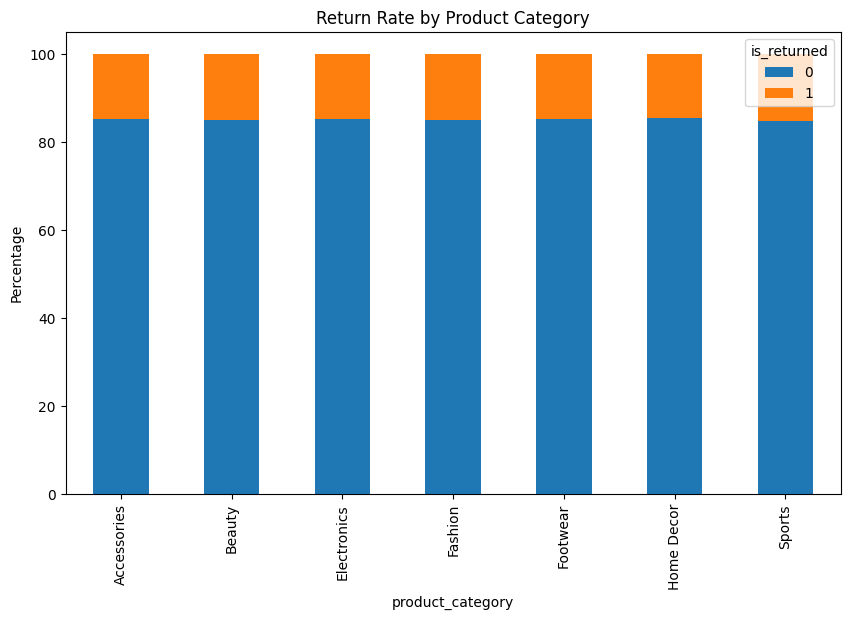

In [25]:
# Cross-tab: product_category vs is_returned
cross_tab = pd.crosstab(Shopify['product_category'], Shopify['is_returned'], normalize='index') * 100
cross_tab=cross_tab.round(2)
print("Return Rate (%) by Product Category:")
print(cross_tab)

cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Return Rate by Product Category")
plt.ylabel("Percentage")
plt.show()

Return Rate (%) by Customer Country:
is_returned           0      1
customer_country              
Australia         85.17  14.83
Canada            84.71  15.29
Germany           84.57  15.43
India             85.38  14.62
UAE               85.16  14.84
UK                85.68  14.32
USA               85.67  14.33


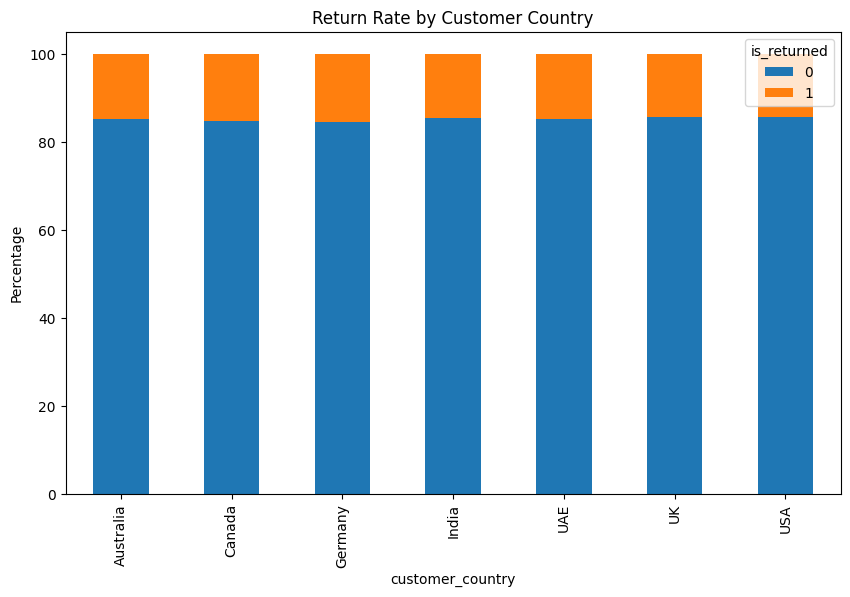

In [26]:
# Cross-tab: customer_country vs is_returned :
country_cross_tab = pd.crosstab(Shopify['customer_country'],Shopify['is_returned'], normalize='index') * 100
country_cross_tab=country_cross_tab.round(2)
print("Return Rate (%) by Customer Country:")
print(country_cross_tab)
country_cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Return Rate by Customer Country")
plt.ylabel("Percentage")
plt.show()

In [ ]:
#.Multivariate Analysis + Outlier Treatment + Feature Engineering:


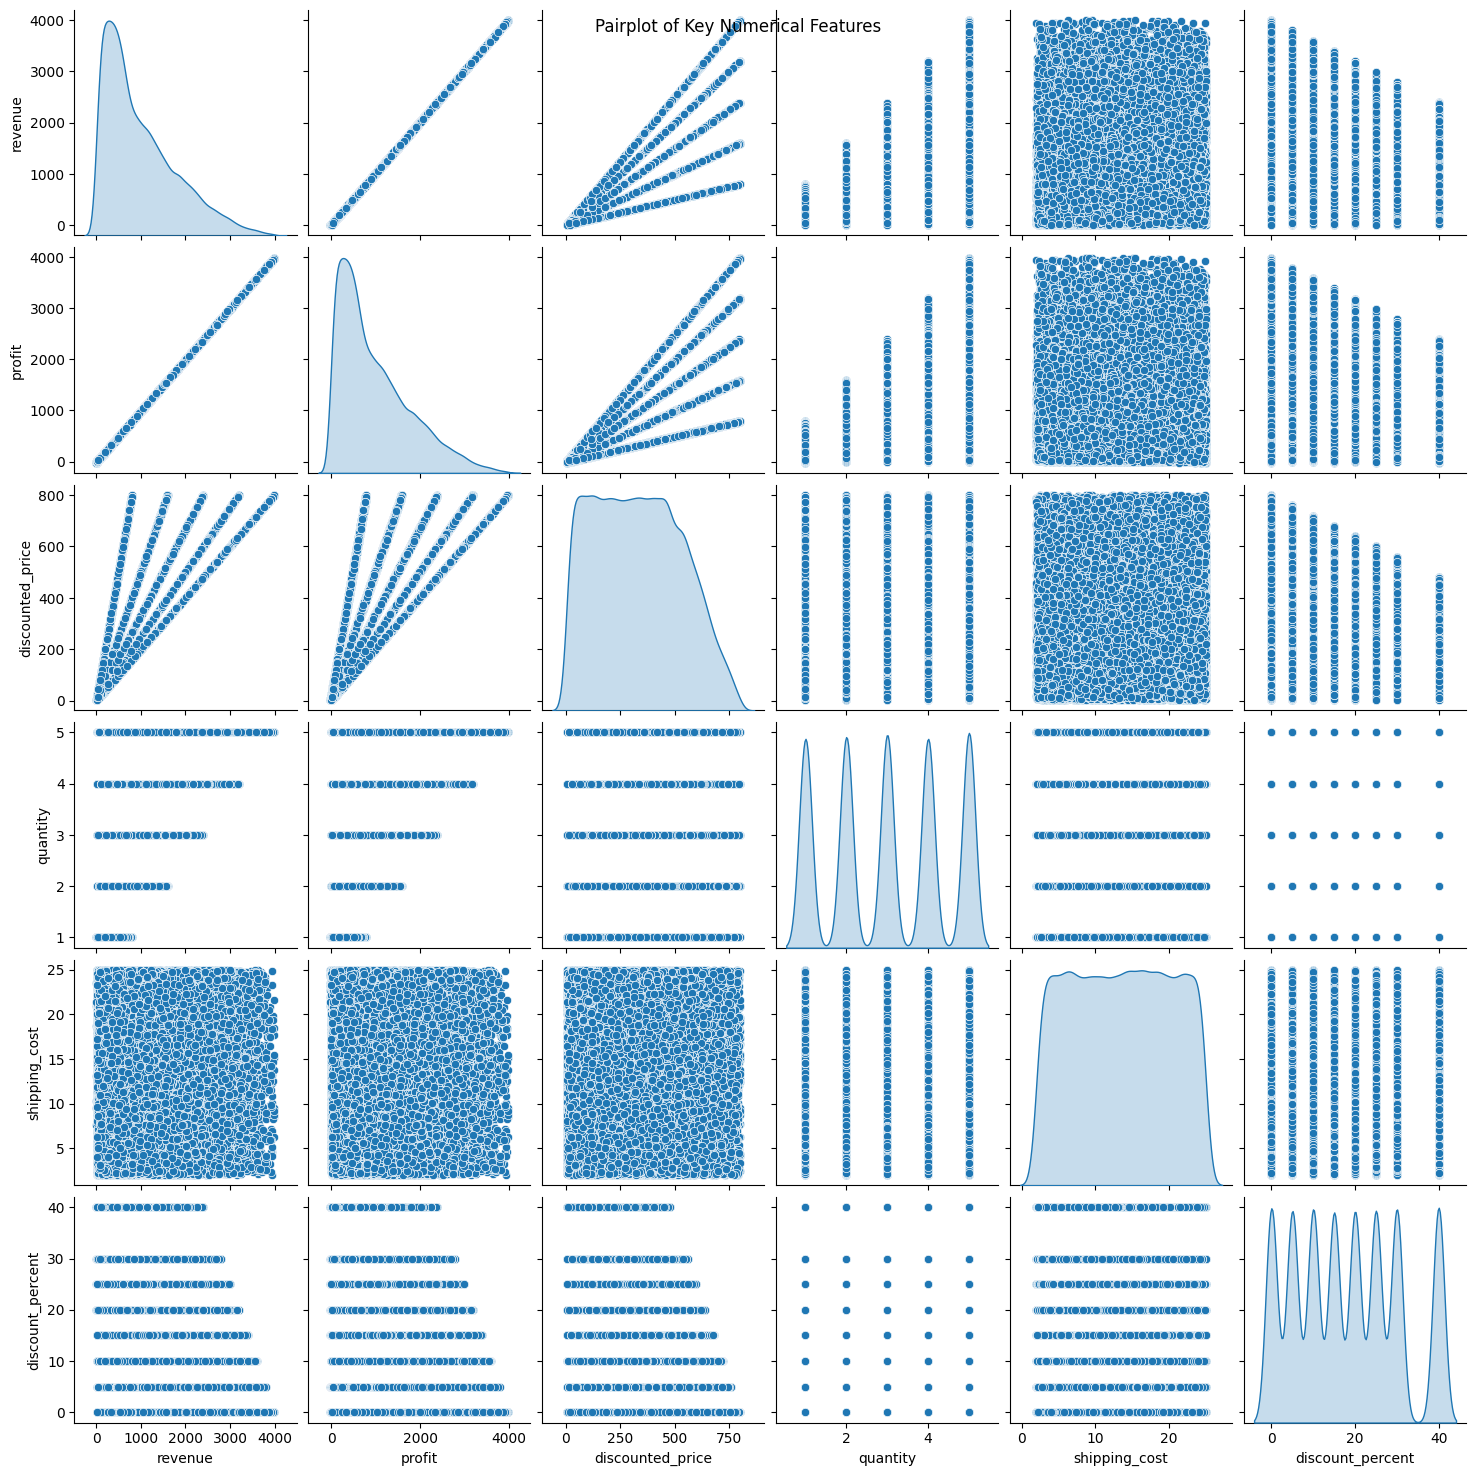

In [27]:
num_features = ['revenue', 'profit', 'discounted_price', 'quantity', 'shipping_cost', 'discount_percent']
sns.pairplot(Shopify[num_features], diag_kind='kde')
plt.suptitle("Pairplot of Key Numerical Features")
plt.show()



In [28]:
# Revenue by Category + Country (pivot)
pivot = Shopify.pivot_table(values='revenue', index='product_category', columns='customer_country', aggfunc='mean').round(2)
print("Average Revenue by Category & Country:")
print(pivot)

Average Revenue by Category & Country:
customer_country  Australia   Canada  Germany    India      UAE       UK  \
product_category                                                           
Accessories         1009.76   983.30   998.28   977.15  1040.05   974.35   
Beauty              1011.21   972.44   997.72  1020.05   996.72   970.24   
Electronics          996.85  1029.81  1013.66  1037.34   996.20  1006.69   
Fashion              996.07   969.59  1034.38   965.47   988.52   973.95   
Footwear             980.74   989.13   985.84   982.38   989.72   984.34   
Home Decor           993.25  1001.18   984.58  1004.32   975.33   984.10   
Sports              1000.02   991.93   953.77   977.42   964.92  1023.57   

customer_country      USA  
product_category           
Accessories       1011.16  
Beauty             997.20  
Electronics        996.46  
Fashion            951.39  
Footwear           999.06  
Home Decor        1013.26  
Sports            1018.00  


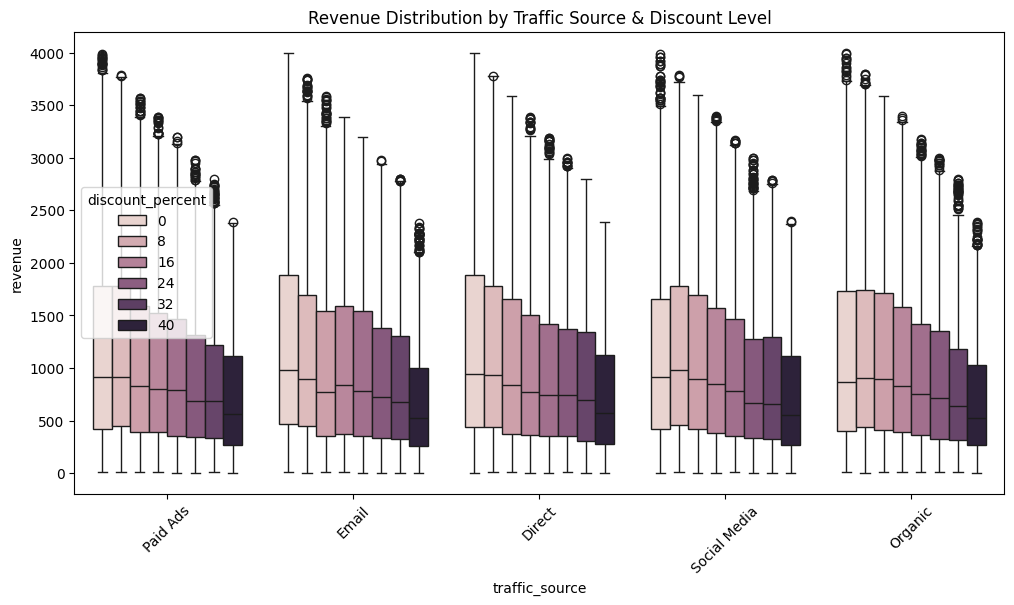

In [29]:


# Discount impact by traffic source
plt.figure(figsize=(12, 6))
sns.boxplot(x='traffic_source', y='revenue', hue='discount_percent', data=Shopify)
plt.title("Revenue Distribution by Traffic Source & Discount Level")
plt.xticks(rotation=45)
plt.show()

revenue capped: new min=23.52, max=3330.96
profit capped: new min=10.46, max=3318.75
quantity capped: new min=1.00, max=5.00
===== Univariate Analysis =====
Column: revenue
Count          : 60,000
Mean           : 991.7182
Median         : 760.4700
Mode           : 23.5199
Standard Dev   : 798.6016
Variance       : 637,764.5081
Minimum        : 23.5199
Maximum        : 3,330.9605
Range          : 3,307.4406
Skewness       : 0.9640
Kurtosis       : 0.1863
25th Percentile: 355.6200
75th Percentile: 1,462.4500
IQR            : 1,106.8300
Missing Values : 0 (0.00%)
----------------------------------------


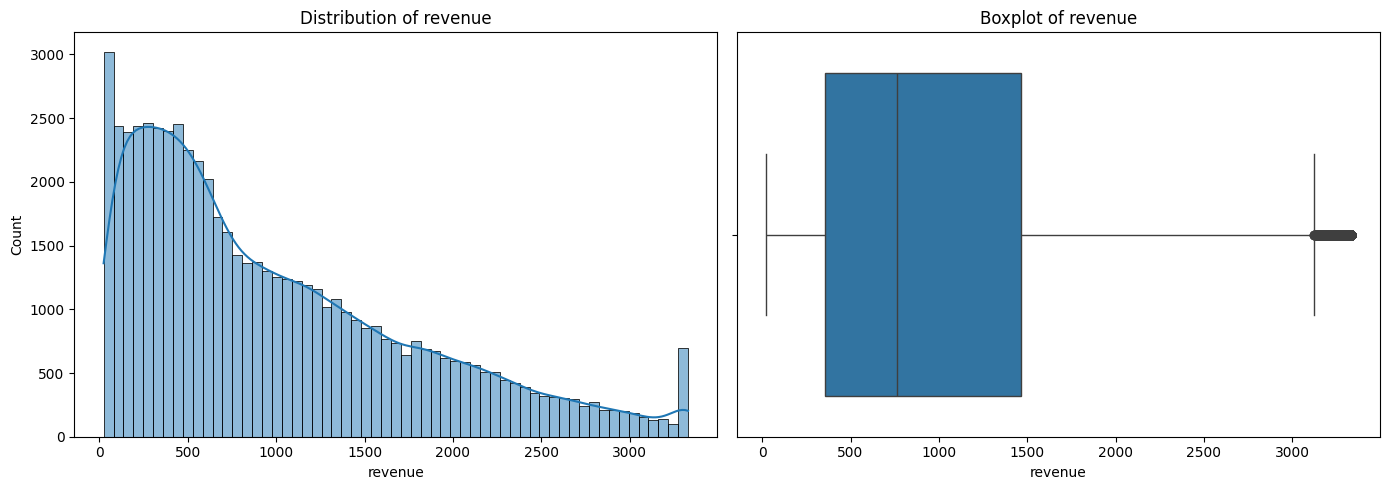

In [30]:
# Outlier Treatment: Capping at 1st/99th percentile (preserves high-value orders)
def cap_outliers(df, column):
    lower = df[column].quantile(0.01)
    upper = df[column].quantile(0.99)
    df[column] = df[column].clip(lower, upper)
    print(f"{column} capped: new min={df[column].min():.2f}, max={df[column].max():.2f}")
    return df

# Apply to key columns
for col in ['revenue', 'profit', 'quantity']:
    Shopify = cap_outliers(Shopify, col)

# Compare before/after univariate (revenue)
univariate_analysis(Shopify, 'revenue')
plot_univariate(Shopify['revenue'])

In [33]:
# Ensure datetime and extract features
Shopify['order_date'] = pd.to_datetime(Shopify['order_date'])
Shopify['year'] = Shopify['order_date'].dt.year
Shopify['month'] = Shopify['order_date'].dt.month
Shopify['year_month'] = Shopify['order_date'].dt.to_period('M')

# Quick consistency check
Shopify['calc_revenue'] = Shopify['discounted_price'] * Shopify['quantity']
print("Revenue mismatch count:", abs(Shopify['revenue'] - Shopify['calc_revenue']).gt(0.01).sum())

Revenue mismatch count: 1199


In [34]:
# New features
Shopify['total_cost'] = Shopify['discounted_price'] * Shopify['quantity'] + Shopify['shipping_cost']
Shopify['profit_margin'] = (Shopify['profit'] / Shopify['total_cost']) * 100
Shopify['is_high_value'] = (Shopify['revenue'] > Shopify['revenue'].quantile(0.75)).astype(int)
Shopify['season'] = Shopify['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                           3: 'Spring', 4: 'Spring', 5: 'Spring',
                                           6: 'Summer', 7: 'Summer', 8: 'Summer',
                                           9: 'Fall', 10: 'Fall', 11: 'Fall'})

print("New features added. Sample:")
print(Shopify[['revenue', 'profit_margin', 'season']].head())

New features added. Sample:
   revenue  profit_margin  season
0    86.03      60.638596  Spring
1  2538.08      99.569108  Spring
2  3045.05      99.262512  Spring
3  1537.17      97.530182    Fall
4   935.76      94.807953  Spring


===== Bivariate: product_price vs revenue =====
Correlation with revenue: 0.7081


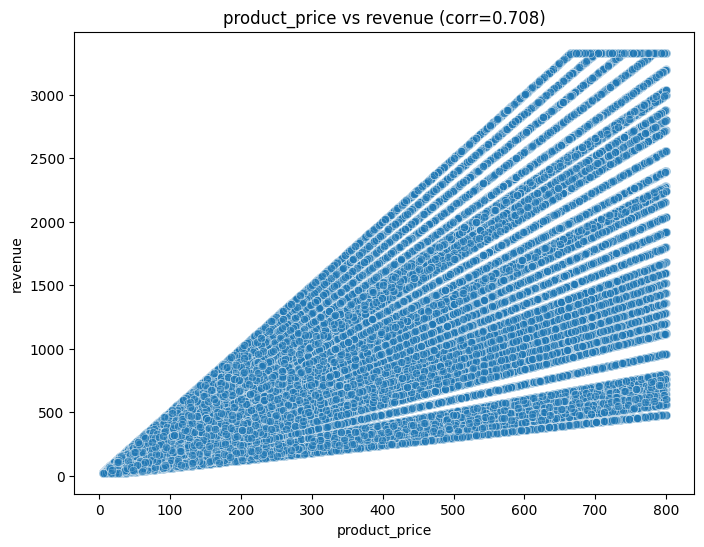

===== Bivariate: revenue vs revenue =====
                   count         mean         std      min       25%      50%  \
product_category                                                                
Accessories       8617.0   996.737032  797.879519  23.5199  360.0200  760.920   
Beauty            8586.0   992.756234  805.811131  23.5199  348.5025  762.105   
Electronics       8624.0  1007.758207  810.119943  23.5199  358.9050  772.410   
Fashion           8594.0   980.641429  790.753858  23.5199  351.0425  754.270   
Footwear          8457.0   984.553924  799.588403  23.5199  355.0500  754.920   
Home Decor        8600.0   991.420477  797.214115  23.5199  351.7825  763.280   
Sports            8522.0   987.945900  788.508262  23.5199  362.8550  760.325   

                        75%        max  
product_category                        
Accessories       1480.1500  3330.9605  
Beauty            1460.8850  3330.9605  
Electronics       1480.5650  3330.9605  
Fashion           1448.

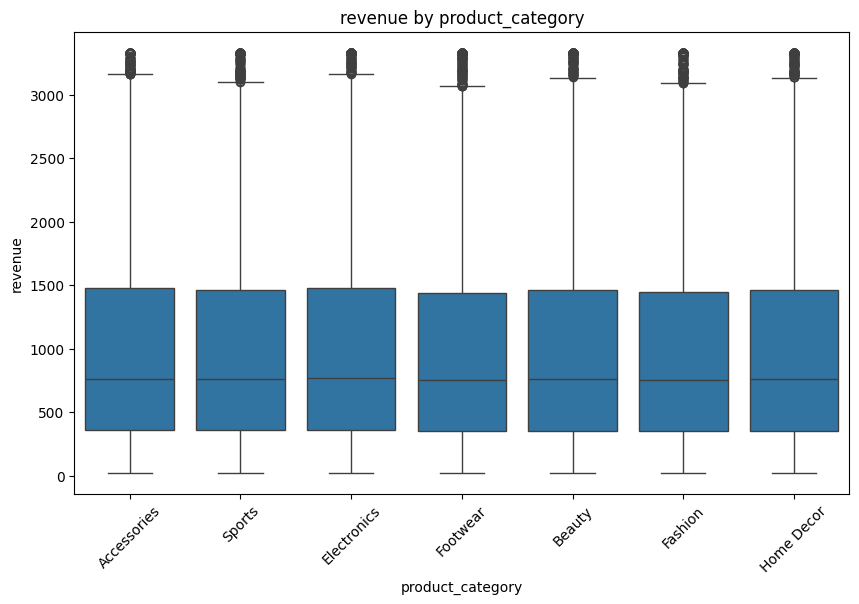

===== Bivariate: revenue vs revenue =====
                   count        mean         std      min       25%      50%  \
customer_country                                                               
Australia         8714.0  995.883488  803.378666  23.5199  350.0750  755.070   
Canada            8586.0  988.188384  795.164115  23.5199  357.5200  758.910   
Germany           8606.0  993.188903  797.140615  23.5199  363.5300  757.350   
India             8554.0  992.284020  801.072816  23.5199  357.6525  758.625   
UAE               8599.0  990.660556  798.052772  23.5199  353.9550  766.080   
UK                8472.0  985.902902  798.629585  23.5199  346.9800  755.340   
USA               8469.0  995.836103  796.889426  23.5199  357.2500  774.120   

                        75%        max  
customer_country                        
Australia         1483.1175  3330.9605  
Canada            1445.6075  3330.9605  
Germany           1461.0875  3330.9605  
India             1454.8050  333

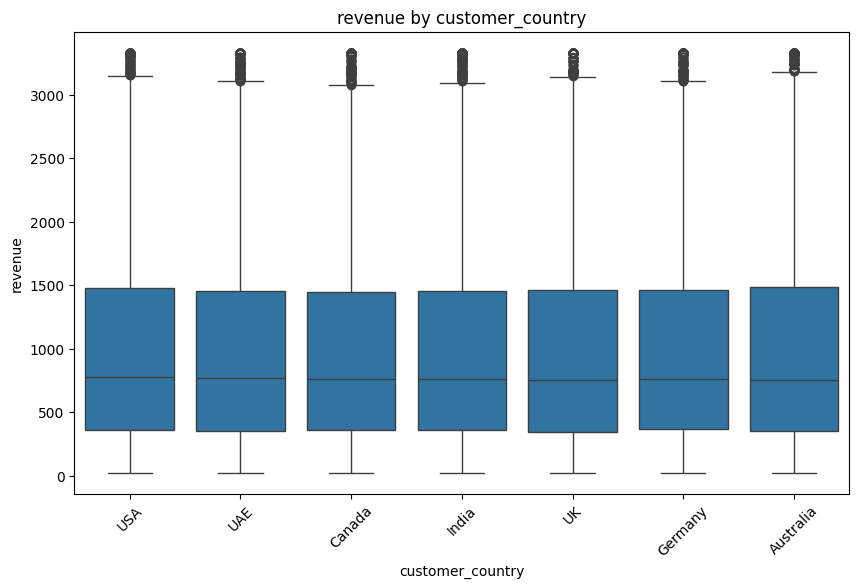

In [35]:
def bivariate_analysis(df, num_col, cat_col=None, target='revenue'):
    print(f"===== Bivariate: {num_col} vs {target or cat_col} =====")

    if cat_col:
        # Categorical vs Numerical
        print(df.groupby(cat_col)[num_col].describe())
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=cat_col, y=num_col, data=df)
        plt.xticks(rotation=45)
        plt.title(f'{num_col} by {cat_col}')
        plt.show()
    else:
        # Numerical vs Numerical (correlation + scatter)
        corr = df[[num_col, target]].corr().iloc[0,1]
        print(f"Correlation with {target}: {corr:.4f}")
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=num_col, y=target, data=df, alpha=0.5)
        plt.title(f'{num_col} vs {target} (corr={corr:.3f})')
        plt.show()

# Examples
bivariate_analysis(Shopify, 'product_price', target='revenue')
bivariate_analysis(Shopify, 'revenue', cat_col='product_category')
bivariate_analysis(Shopify, 'revenue', cat_col='customer_country')

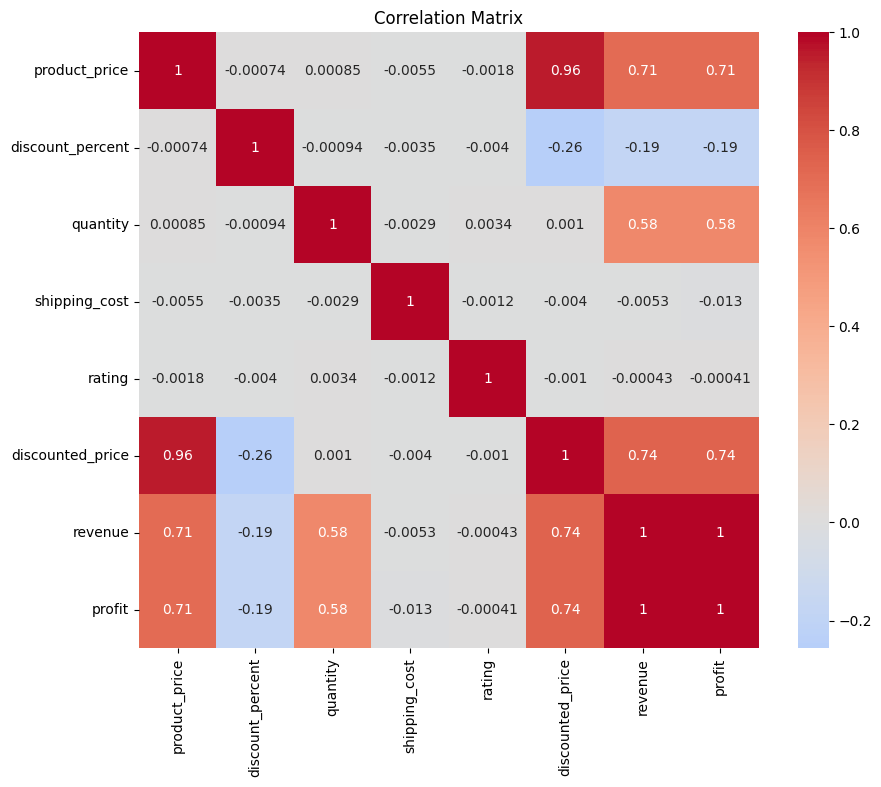

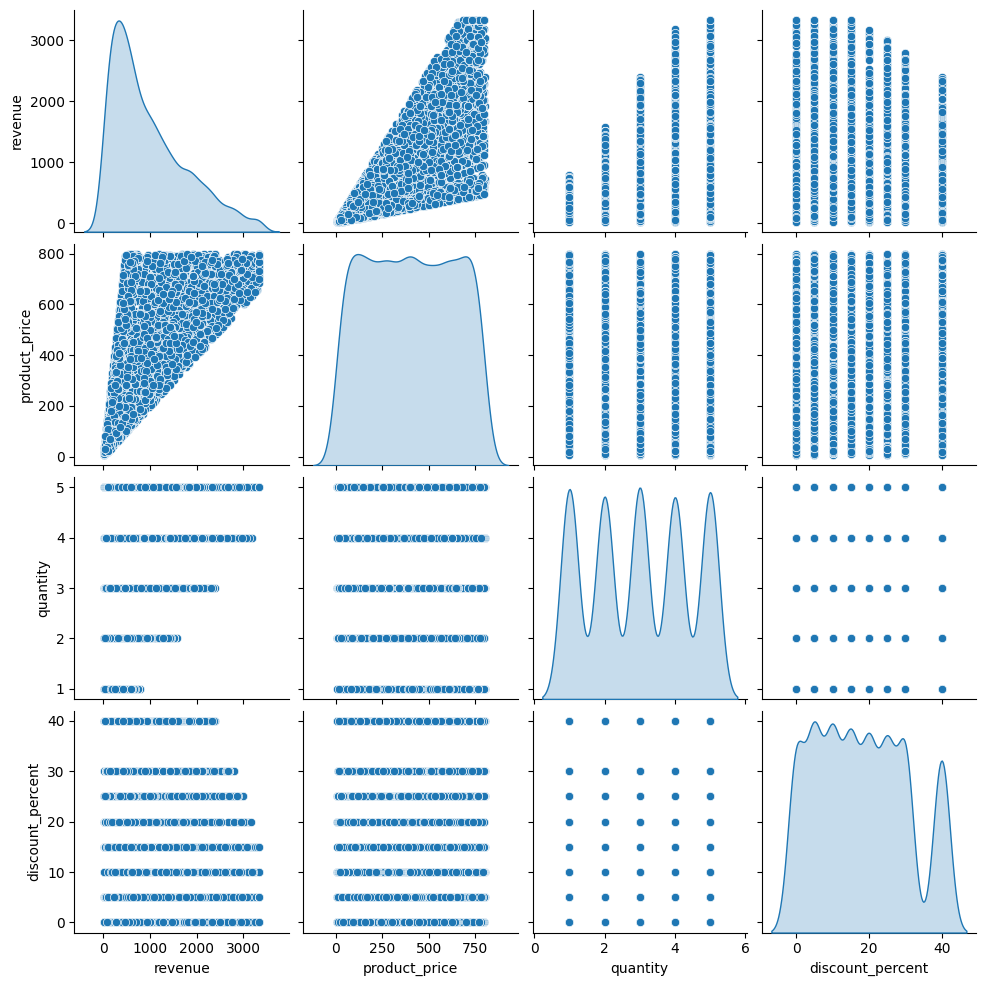

In [36]:
# Correlation heatmap (numerical features)
num_cols = ['product_price', 'discount_percent', 'quantity', 'shipping_cost',
            'rating', 'discounted_price', 'revenue', 'profit']
plt.figure(figsize=(10, 8))
sns.heatmap(Shopify[num_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Pairplot sample (for key variables)
sns.pairplot(Shopify[['revenue', 'product_price', 'quantity', 'discount_percent']].sample(5000), diag_kind='kde')
plt.show()


In [37]:
def treat_outliers(df, column, method='cap'):
    lower, upper, _ = detect_outliers(df, column)  # reuse your function
    if method == 'cap':
        df[column] = df[column].clip(lower=lower, upper=upper)
    # or remove: df = df[(df[column] >= lower) & (df[column] <= upper)]
    return df

# Example
Shopify = treat_outliers(Shopify.copy(), 'revenue')

revenue: 1014 outliers (1.69%)


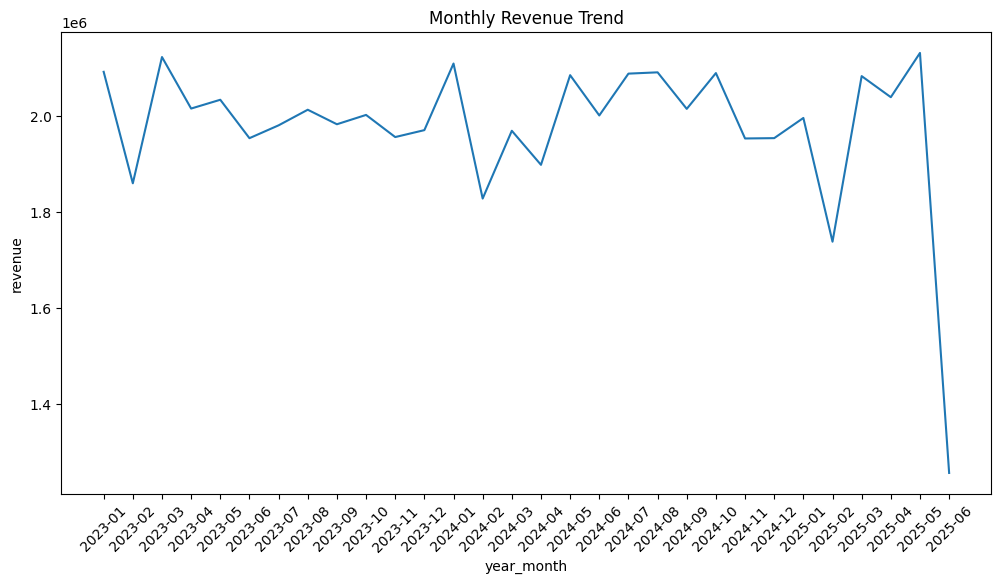

In [38]:
# Monthly revenue trend
monthly = Shopify.groupby('year_month')['revenue'].sum().reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(x='year_month', y='revenue', data=monthly)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.show()

In [39]:
import sqlite3 as sql

In [58]:
conn = sql.connect('Shopify.db')
Shopify.to_sql("Financials",conn,if_exists='replace',index=False)

60000

In [59]:
##.Country wise Customer Count,Product Count,Return Percentage:
country_wise = pd.read_sql("""
SELECT customer_country,
COUNT(DISTINCT customer_id) AS CUSTOMER_COUNT,
COUNT(DISTINCT product_id) AS PRODUCT_COUNT,
ROUND(SUM(CASE WHEN is_returned = 1 THEN 1 ELSE 0 END)*100/COUNT(DISTINCT order_id),2) AS RETURN_PERCENTAGE
FROM Financials
GROUP BY customer_country
ORDER BY CUSTOMER_COUNT DESC
""",conn)
country_wise

,customer_country,CUSTOMER_COUNT,PRODUCT_COUNT,RETURN_PERCENTAGE
0,Australia,7858,4940,14.0
1,Germany,7766,4948,15.0
2,India,7735,4929,14.0
3,UAE,7711,4981,14.0
4,Canada,7711,4940,15.0
5,UK,7658,4925,14.0
6,USA,7606,4947,14.0


In [60]:
###.Highest And Lowest Selling Products with profit,Discount and Fright Charge Comparision:
Highest_Selling = pd.read_sql("""
SELECT product_category,
COUNT(DISTINCT product_id) AS PRODUCT_COUNT,
ROUND(SUM(revenue),2) AS REVENUE,
ROUND(SUM(profit),2) AS PROFIT,
ROUND(SUM(discounted_price),2) AS DISCOUNTED_PRICE,
ROUND(SUM(shipping_cost),2) AS SHIPPING_COST
FROM Financials
GROUP BY product_category
""",conn)
Highest_Selling

,product_category,PRODUCT_COUNT,REVENUE,PROFIT,DISCOUNTED_PRICE,SHIPPING_COST
0,Accessories,4968,8566362.14,8472849.90,2844533.93,116232.62
1,Beauty,4957,8498781.32,8408387.58,2844109.52,115805.35
2,Electronics,4958,8661776.85,8574984.19,2874477.23,116233.48
3,Fashion,4997,8406230.97,8310675.06,2799169.96,117228.52
4,Footwear,4896,8300753.54,8212750.47,2785860.92,113860.14
5,Home Decor,4966,8504103.09,8409198.58,2837881.62,117176.31
6,Sports,4916,8400145.70,8304596.44,2827179.54,114769.06


In [61]:
###.Countyywise revenue and profits:
Country_wise_revenue = pd.read_sql("""
SELECT customer_country,
SUM(revenue) AS REVENUE,
SUM(profit) AS PROFITS,
ROUND(SUM(revenue)/SUM(profit)*100,2) AS PROFIT_MARGIN
FROM Financials
GROUP BY customer_country
ORDER BY REVENUE DESC
""",conn)
Country_wise_revenue

,customer_country,REVENUE,PROFITS,PROFIT_MARGIN
0,Australia,8.654604e+06,8.560370e+06,101.10
1,Germany,8.523259e+06,8.431017e+06,101.09
2,UAE,8.495262e+06,8.402277e+06,101.11
3,India,8.462381e+06,8.372380e+06,101.07
4,Canada,8.459652e+06,8.369254e+06,101.08
5,USA,8.413263e+06,8.319807e+06,101.12
6,UK,8.329732e+06,8.238339e+06,101.11


In [62]:
###.Product Wise return Percentage:
Product_Return = pd.read_sql("""
SELECT product_category,
ROUND(SUM(CASE WHEN is_returned	=1 THEN 1 ELSE 0 END)*100/COUNT(DISTINCT order_id),2) AS RETURN_PERCENTAGE
FROM Financials
GROUP BY product_category
ORDER BY RETURN_PERCENTAGE DESC
""",conn)
Product_Return

,product_category,RETURN_PERCENTAGE
0,Sports,15.0
1,Fashion,15.0
2,Beauty,15.0
3,Home Decor,14.0
4,Footwear,14.0
5,Electronics,14.0
6,Accessories,14.0


In [63]:
###traffic_source generate High Profits:
Traffic_Source = pd.read_sql("""
SELECT traffic_source,
ROUND(SUM(profit),2) AS PROFITS
FROM Financials
GROUP BY traffic_source
ORDER BY PROFITS DESC
""",conn)
Traffic_Source

,traffic_source,PROFITS
0,Social Media,11837771.00
1,Direct,11762807.71
2,Paid Ads,11743452.12
3,Organic,11718297.15
4,Email,11631114.22


In [64]:
###.Payment Method And Customer Counts:
Payment_Method_customers = pd.read_sql("""
SELECT payment_method,
COUNT(DISTINCT customer_id) AS CUSTOMER_COUNT,
SUM(revenue) AS REVENUE,
SUM(profit)AS PROFITS	,
SUM(discounted_price) AS DISCOUNTED_PRICE,
SUM(shipping_cost) AS SHIPPING_COST,
SUM(profit_margin) AS PROFIT_MARGINS
FROM Financials
GROUP BY payment_method
ORDER BY CUSTOMER_COUNT DESC
""",conn)
Payment_Method_customers

,payment_method,CUSTOMER_COUNT,REVENUE,PROFITS,DISCOUNTED_PRICE,SHIPPING_COST,PROFIT_MARGINS
0,Apple Pay,10485,1.203897e+07,1.191257e+07,4003183.11,163864.61,1.124133e+06
1,Cash on Delivery,10406,1.181297e+07,1.168350e+07,3968505.94,162031.13,1.117285e+06
2,Credit Card,10358,1.183571e+07,1.170694e+07,3954414.33,162578.30,1.114135e+06
3,Debit Card,10308,1.185275e+07,1.172015e+07,3935088.15,161409.15,1.106431e+06
4,PayPal,10288,1.179777e+07,1.167028e+07,3952021.19,161422.29,1.105776e+06


In [65]:
Query = pd.read_sql("""
select * from Financials
LIMIT 5 """,conn)
Query

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,...,revenue,profit,total_cost,profit_margin,is_high_value,year,month,year_month,calc_revenue,season
0,1,2023-04-13 00:00:00,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,...,86.03,64.95,107.11,60.638596,0,2023,4,2023-04,86.03,Spring
1,2,2024-03-11 00:00:00,26825,5557,Sports,746.49,15,4,UAE,Email,...,2538.08,2532.60,2543.56,99.569108,1,2024,3,2024-03,2538.08,Spring
2,3,2025-05-10 00:00:00,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,...,3045.05,3033.78,3056.32,99.262512,1,2025,5,2025-05,3045.05,Spring
3,4,2023-09-28 00:00:00,20691,7855,Footwear,512.39,0,3,UAE,Direct,...,1537.17,1517.95,1556.39,97.530182,1,2023,9,2023-09,1537.17,Fall
4,5,2023-04-17 00:00:00,24631,7789,Sports,415.89,25,3,UAE,Social Media,...,935.76,910.82,960.70,94.807953,0,2023,4,2023-04,935.76,Spring


In [66]:
###.Revenue Trend Over Month:
Revenue_Trend = pd.read_sql("""
SELECT STRFTIME('%Y',order_date) AS YEAR,
STRFTIME('%m',order_date) AS MONTH,
SUM(revenue) AS REVENUE,
LAG (revenue) OVER (PARTITION BY STRFTIME('%M',order_date) ORDER BY SUM(revenue) DESC  ) REVENUE_TREND
FROM Financials
GROUP BY YEAR,MONTH
ORDER BY YEAR,MONTH

""",conn)
Revenue_Trend

,YEAR,MONTH,REVENUE,REVENUE_TREND
0,2023,01,2.093211e+06,647.96
1,2023,02,1.860569e+06,83.06
2,2023,03,2.124065e+06,3045.05
3,2023,04,2.016562e+06,509.16
4,2023,05,2.034910e+06,668.45
5,2023,06,1.954743e+06,207.55
6,2023,07,1.981532e+06,1537.17
7,2023,08,2.014091e+06,335.14
8,2023,09,1.983796e+06,2287.00
9,2023,10,2.003272e+06,371.72


In [67]:
### Top Performing Categories & Countries:
Top_Categories = pd.read_sql("""
SELECT * FROM (SELECT product_category,
customer_country,
SUM(revenue) AS REVENUE,
ROW_NUMBER () OVER(PARTITION BY product_category ORDER BY SUM(revenue) DESC) AS RANK
FROM Financials
GROUP BY product_category,customer_country
ORDER BY REVENUE DESC)
WHERE RANK==1
""",conn)
Top_Categories

,product_category,customer_country,REVENUE,RANK
0,Sports,Australia,1.288018e+06,1
1,Beauty,Australia,1.279864e+06,1
2,Accessories,Germany,1.270613e+06,1
3,Electronics,Germany,1.265241e+06,1
4,Fashion,Germany,1.248985e+06,1
5,Home Decor,India,1.234501e+06,1
6,Footwear,Australia,1.224309e+06,1


In [68]:
###. Statistical Analysis:
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import levene

In [69]:
contingency_table = pd.crosstab(
    Shopify['product_category'],
    Shopify['is_returned']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic :", chi2)
print("P-value :", p)

alpha = 0.05

if p < alpha:
    print("Reject H0")
    print("Product Category and Return Status are associated.")
else:
    print("Fail to Reject H0")
    print("No significant association.")

Chi-Square Statistic : 3.247087292695668
P-value : 0.7772566598853468
Fail to Reject H0
No significant association.


In [70]:
returned = Shopify[Shopify['is_returned']==1]['profit']

not_returned = Shopify[
    Shopify['is_returned']==0
]['profit']

t_stat, p = ttest_ind(returned, not_returned)

print("T Statistic :", t_stat)
print("P-value :", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

T Statistic : -0.7001799066954695
P-value : 0.48381767327798086
Fail to Reject H0


In [78]:
### Payment Method vs Return Status:

In [79]:
groups = []

for category in Shopify['product_category'].unique():
    groups.append(
        Shopify[
            Shopify['product_category']==category
        ]['profit']
    )

f_stat, p = f_oneway(*groups)

print("F Statistic :", f_stat)
print("P-value :", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

F Statistic : 1.0677768977060365
P-value : 0.3792224433905923
Fail to Reject H0


In [83]:
## Pearson Correlation
##Discount vs Profit

In [84]:
corr, p = pearsonr(
    Shopify['discounted_price'],
    Shopify['profit']
)

print("Correlation :", corr)
print("P-value :", p)

Correlation : 0.739742052633945
P-value : 0.0


In [73]:
stat, p = shapiro(Shopify['profit'])

print("Statistic :", stat)
print("P-value :", p)

if p > 0.05:
    print("Normally Distributed")
else:
    print("Not Normally Distributed")

Statistic : 0.905508643825904
P-value : 1.476267430059948e-99
Not Normally Distributed


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 60000.
  res = hypotest_fun_out(*samples, **kwds)


In [74]:
stat, p = levene(*groups)

print("Statistic :", stat)
print("P-value :", p)

if p > 0.05:
    print("Equal Variance")
else:
    print("Unequal Variance")

Statistic : 1.212432522818132
P-value : 0.2962149722362081
Equal Variance


In [77]:
### Payment Method vs Return Status:

In [76]:
table = pd.crosstab(Shopify['payment_method'],
                    Shopify['is_returned'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Chi-Square Statistic: 6.9436280568614475
P-value: 0.13889738176077376
Fail to Reject H0


In [80]:
#Traffic Source vs Revenue:

In [81]:
groups = []

for source in Shopify['traffic_source'].unique():
    groups.append(
        Shopify[Shopify['traffic_source']==source]['revenue']
    )

f_stat, p = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

F Statistic: 0.6514246908078639
P-value: 0.6258162738871094
Fail to Reject H0


In [82]:
corr, p = pearsonr(
    Shopify['discount_percent'],
    Shopify['profit']
)

print("Correlation:", corr)
print("P-value:", p)

Correlation: -0.18667365435879274
P-value: 0.0


In [85]:
##Pearson Correlation
##Shipping Cost vs Profit

In [86]:
corr, p = pearsonr(
    Shopify['shipping_cost'],
    Shopify['profit']
)

print("Correlation:", corr)
print("P-value:", p)

Correlation: -0.013376617352163583
P-value: 0.0010504016581351268


In [87]:
## Pearson Correlation
##Rating vs Revenue

In [88]:
corr, p = pearsonr(
    Shopify['rating'],
    Shopify['revenue']
)

print("Correlation:", corr)
print("P-value:", p)

Correlation: -0.00044059030358630305
P-value: 0.9140592315729681


In [89]:
##.Predictive Analysis:

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [91]:
Shopify_ml = Shopify.copy()

le = LabelEncoder()

categorical_columns = [
    'product_category',
    'customer_country',
    'traffic_source',
    'payment_method'
]

for col in categorical_columns:
    Shopify_ml[col] = le.fit_transform(Shopify_ml[col])

In [95]:
#Linear Regression
#Business Question

#Can we predict Profit using business features?

In [96]:
X = Shopify_ml[
    [
        'product_price',
        'discount_percent',
        'quantity',
        'shipping_cost',
        'rating'
    ]
]

y = Shopify_ml['profit']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [98]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [99]:
##.Prediction

In [100]:
y_pred = lr.predict(X_test)

In [101]:
print("R² Score :", r2_score(y_test, y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE :", rmse)

R² Score : 0.8732305149914844
MAE : 214.40299936833603
RMSE : 285.8173931039383


In [102]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,quantity,327.017173
0,product_price,2.454126
3,shipping_cost,-1.114936
4,rating,-1.210358
1,discount_percent,-11.820304


In [ ]:
## Decision Tree Classification
##Business Question

##Can we predict whether an order will be returned?

In [103]:
X = Shopify_ml[
    [
        'product_price',
        'discount_percent',
        'quantity',
        'shipping_cost',
        'rating',
        'product_category',
        'customer_country',
        'traffic_source',
        'payment_method'
    ]
]

y = Shopify_ml['is_returned']

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [106]:
y_pred = dt.predict(X_test)

In [107]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8549166666666667
Precision : 0.1
Recall : 0.0005770340450086555
F1 Score : 0.0011474469305794606


In [108]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10258     9]
 [ 1732     1]]


In [109]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.10      0.00      0.00      1733

    accuracy                           0.85     12000
   macro avg       0.48      0.50      0.46     12000
weighted avg       0.75      0.85      0.79     12000



In [110]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,shipping_cost,0.441557
0,product_price,0.230984
4,rating,0.113790
1,discount_percent,0.075585
2,quantity,0.042413
7,traffic_source,0.039967
5,product_category,0.029435
6,customer_country,0.026268
8,payment_method,0.000000


# Business Recommendations

Based on the analyses performed in this project, the following recommendations can help improve business performance:

## 1. Optimize Discount Strategy

Analyze products with high discounts but low profit margins. Reduce unnecessary discounts and introduce targeted promotional campaigns to improve profitability.

## 2. Monitor Shipping Costs

Review products with high shipping costs that negatively affect profit. Consider optimizing logistics or renegotiating shipping rates to reduce operational expenses.

## 3. Improve High Return Categories

Focus on product categories with high return rates by reviewing product quality, improving product descriptions, and strengthening quality control processes.

## 4. Focus on High-Performing Products

Increase inventory availability and marketing efforts for products that consistently generate high sales and profit.

## 5. Improve Low-Performing Products

Investigate products with low sales by evaluating pricing, promotions, customer demand, and product visibility. Consider discontinuing consistently underperforming products.

## 6. Strengthen Customer Experience

Analyze customer ratings and feedback to identify areas for improvement. Enhancing product quality and customer service can increase customer satisfaction and reduce returns.

## 7. Invest in High-Performing Marketing Channels

Allocate more marketing resources to traffic sources that generate higher revenue and better conversion rates while optimizing or reducing spending on lower-performing channels.

## 8. Use Predictive Analytics for Decision-Making

Leverage the developed machine learning models to predict profitability and product returns, enabling proactive inventory planning and targeted business strategies.

## Conclusion

The analysis demonstrates how data-driven decision-making can improve sales performance, optimize operational costs, reduce product returns, and enhance overall business profitability. By integrating exploratory analysis, SQL, statistical testing, predictive modeling, and interactive dashboards, this project provides a comprehensive framework for supporting strategic business decisions.


In [112]:
# Final Export for Power BI + Excel
Shopify.to_csv("shopify_final_cleaned.csv", index=False)
print("File exported successfully: shopify_final_cleaned.csv")
print(f"Rows: {len(Shopify)}, Columns: {len(Shopify.columns)}")

File exported successfully: shopify_final_cleaned.csv
Rows: 60000, Columns: 25
